In [1]:
import os
import pandas as pd
import torch
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from variable_leverage_env_1 import agentDLVEnvV2
from utils import plot_economic_metrics, plot, plot_episode_history_v2

In [2]:
WIDTH = 0.4
TOP_LEVERAGE = 2 + WIDTH/2
BOTTOM_LEVERAGE = 2 - WIDTH/2

In [3]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

In [4]:
eval_env = DummyVecEnv([lambda: agentDLVEnvV2(
            nect_honey_price = nect_price,
            nav_in_honey = nav,
            vol_part = volatile_part,
            vol_token_honey_price = vol_token_price,
            is_mixed = True,
            top_leverage = TOP_LEVERAGE,
            bottom_leverage = BOTTOM_LEVERAGE
)])
#eval_env = VecNormalize.load("variable_leverage_model_recurrent/vecnormalize_stats.pkl", eval_env)
#eval_env.training = False
#eval_env.norm_reward = False

model_1 = RecurrentPPO.load(
    "variable_leverage_model_recurrent/ppo_model_phase_0", 
    env=eval_env,
    custom_objects={"lr_schedule": lambda _: 0.0, "learning_rate": 0.0}
)

model_2 = RecurrentPPO.load(
    "variable_leverage_model_recurrent/ppo_mixed/best_model_1/best_model", 
    env=eval_env,
    custom_objects={"lr_schedule": lambda _: 0.0, "learning_rate": 0.0}
)

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1


6198
6929
doing nothing 99.97924449979244 %
action 1 0.0 %
action 2 0.0 %
action 3 0.0 %


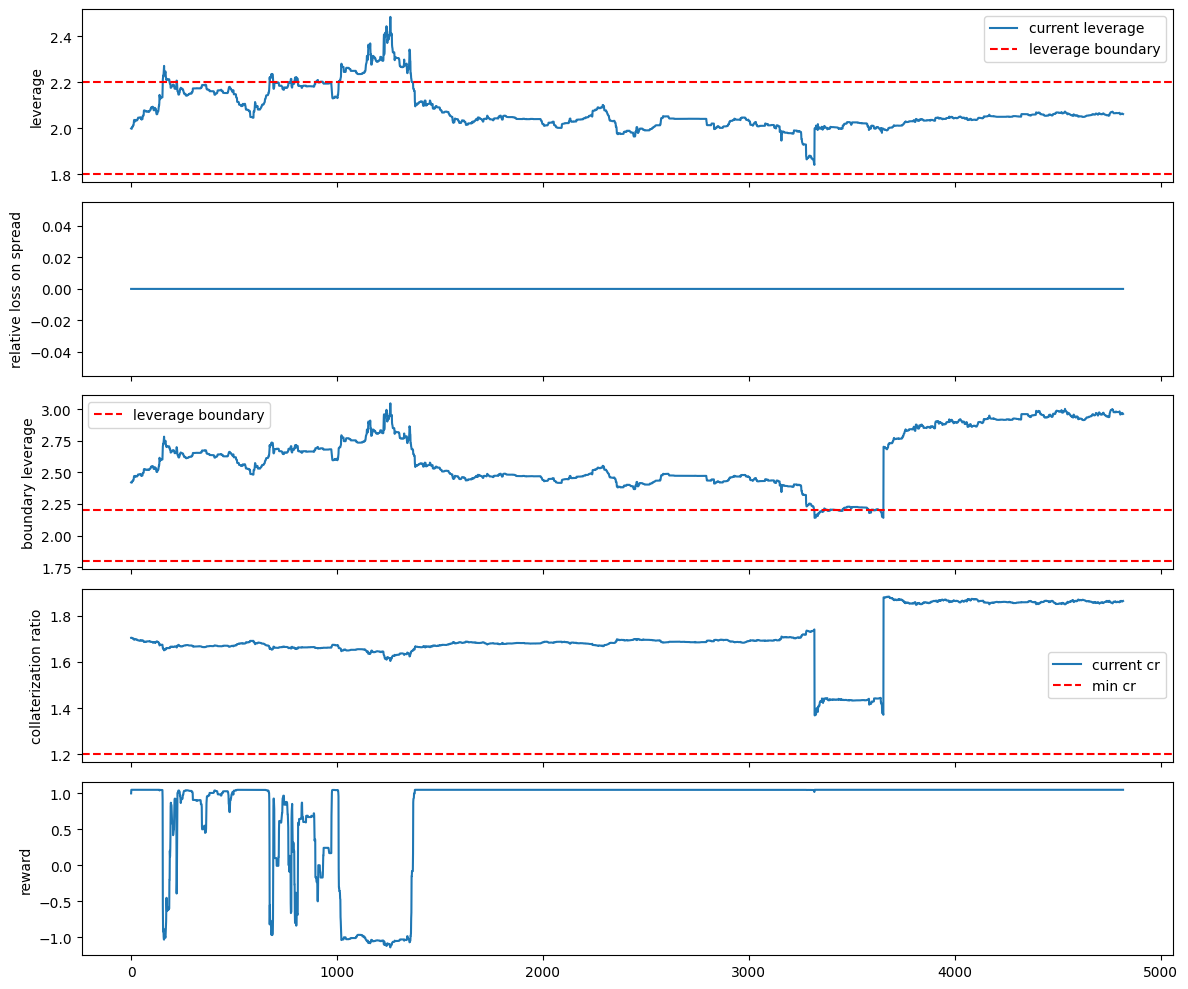

In [5]:
obs = eval_env.reset()   
done = False
while not done:  
    obs, rewards, dones, infos = eval_env.step([0])
    done = dones[0]
    if dones[0]:
        economic_metrics = infos[0].get('episode_economics')
        episode_history = infos[0].get('episode_history')   
        not_doing = infos[0].get('0 action')  
        action_1 = infos[0].get('0.5 rebalancing') 
        action_2 = infos[0].get('0.75 rebalancing') 
        action_3 = infos[0].get('0.25 rebalancing') 
        break

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(episode_history, TOP_LEVERAGE, BOTTOM_LEVERAGE)

2626
2810
doing nothing 99.89622249896223 %
action 1 0.08302200083022 %
action 2 0.0 %
action 3 0.0 %


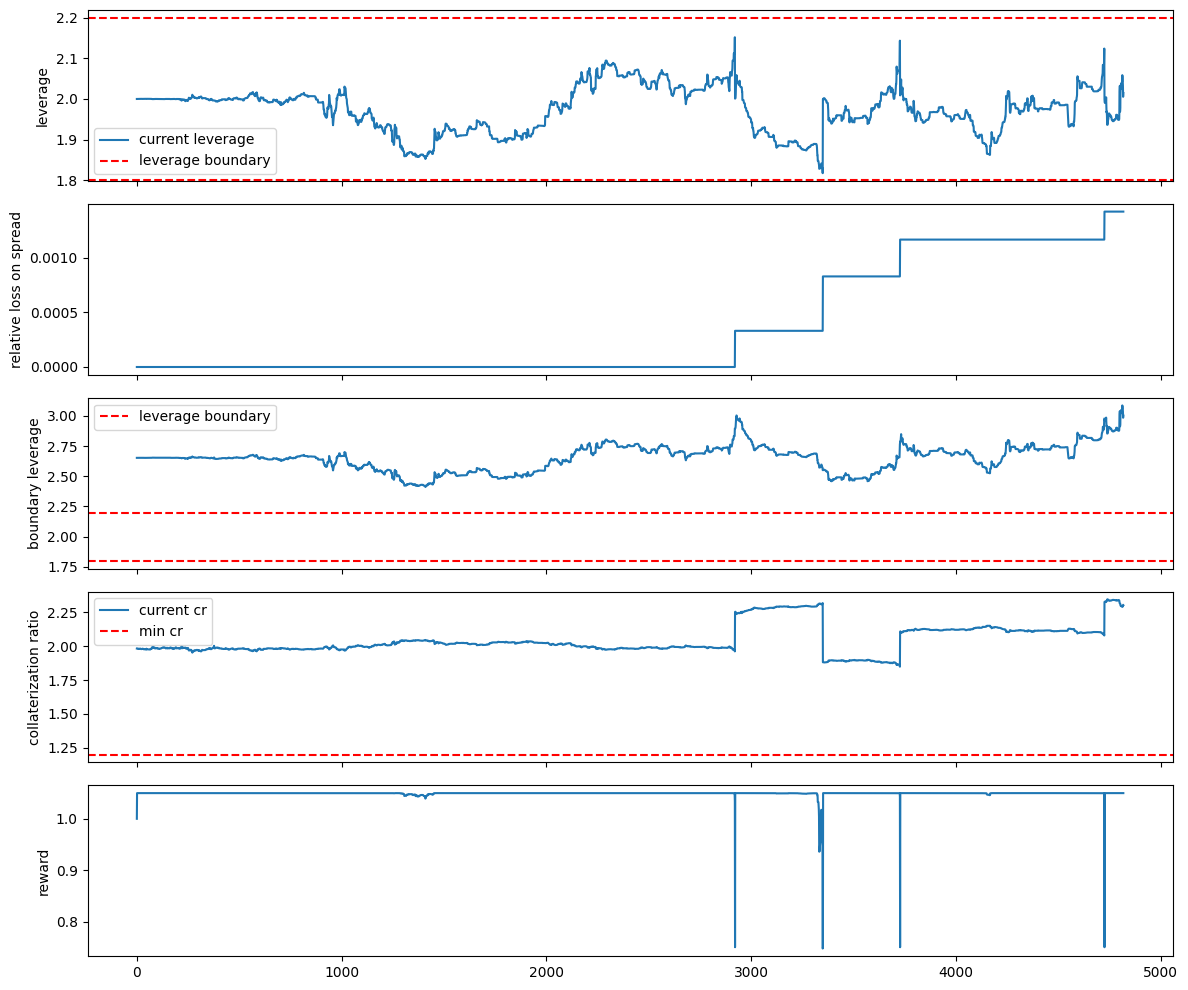

In [6]:
obs = eval_env.reset()   
done = False
while not done:
    action, _ = model_1.predict(obs, deterministic=True)  
    obs, rewards, dones, infos = eval_env.step(action)
    done = dones[0]
    if dones[0]:
        economic_metrics = infos[0].get('episode_economics')
        episode_history = infos[0].get('episode_history')   
        not_doing = infos[0].get('0 action')  
        action_1 = infos[0].get('0.5 rebalancing') 
        action_2 = infos[0].get('0.75 rebalancing') 
        action_3 = infos[0].get('0.25 rebalancing') 
        break

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(episode_history, TOP_LEVERAGE, BOTTOM_LEVERAGE)

5418
3724
doing nothing 99.8547114985471 %
action 1 0.12453300124533001 %
action 2 0.0 %
action 3 0.0 %


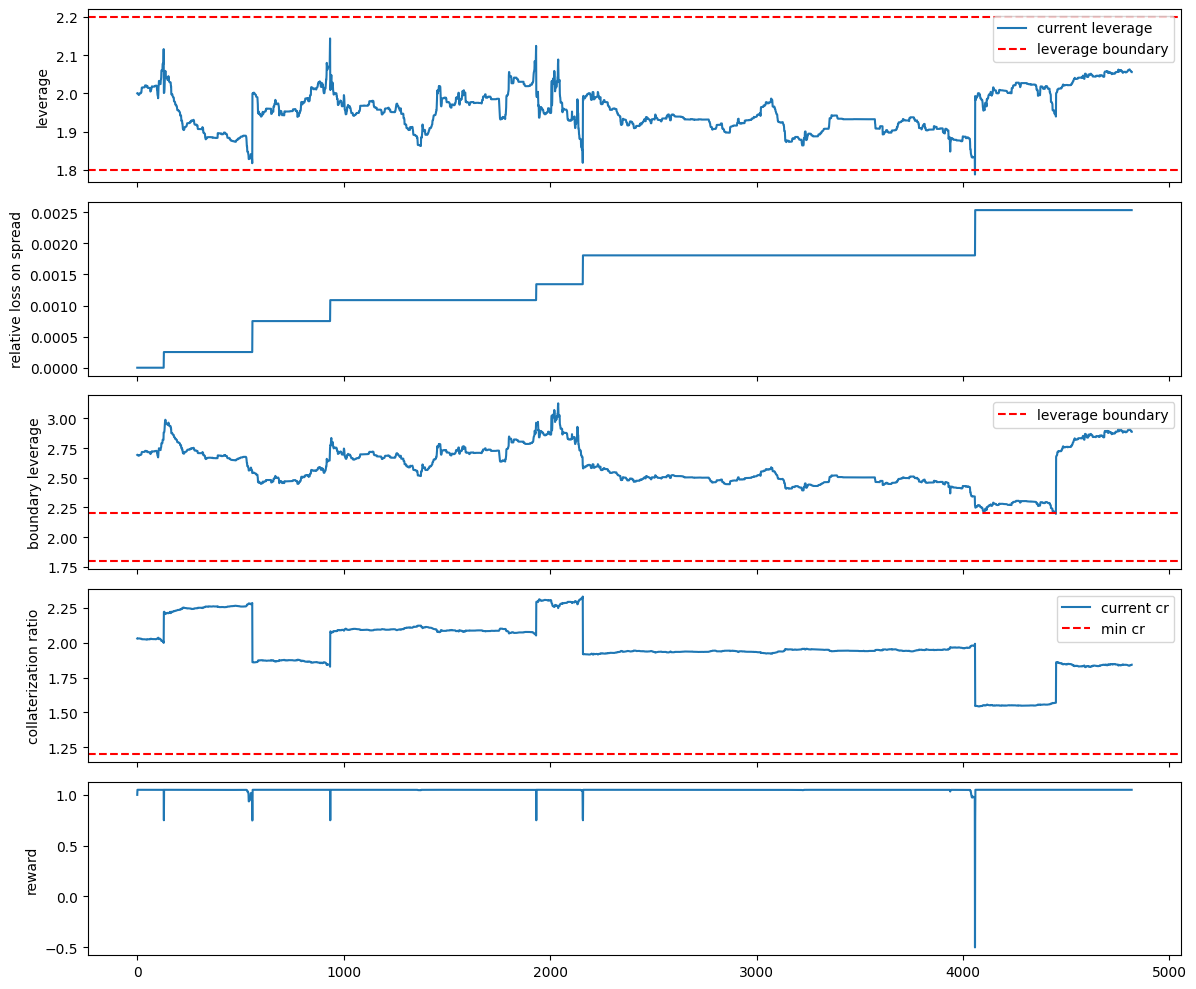

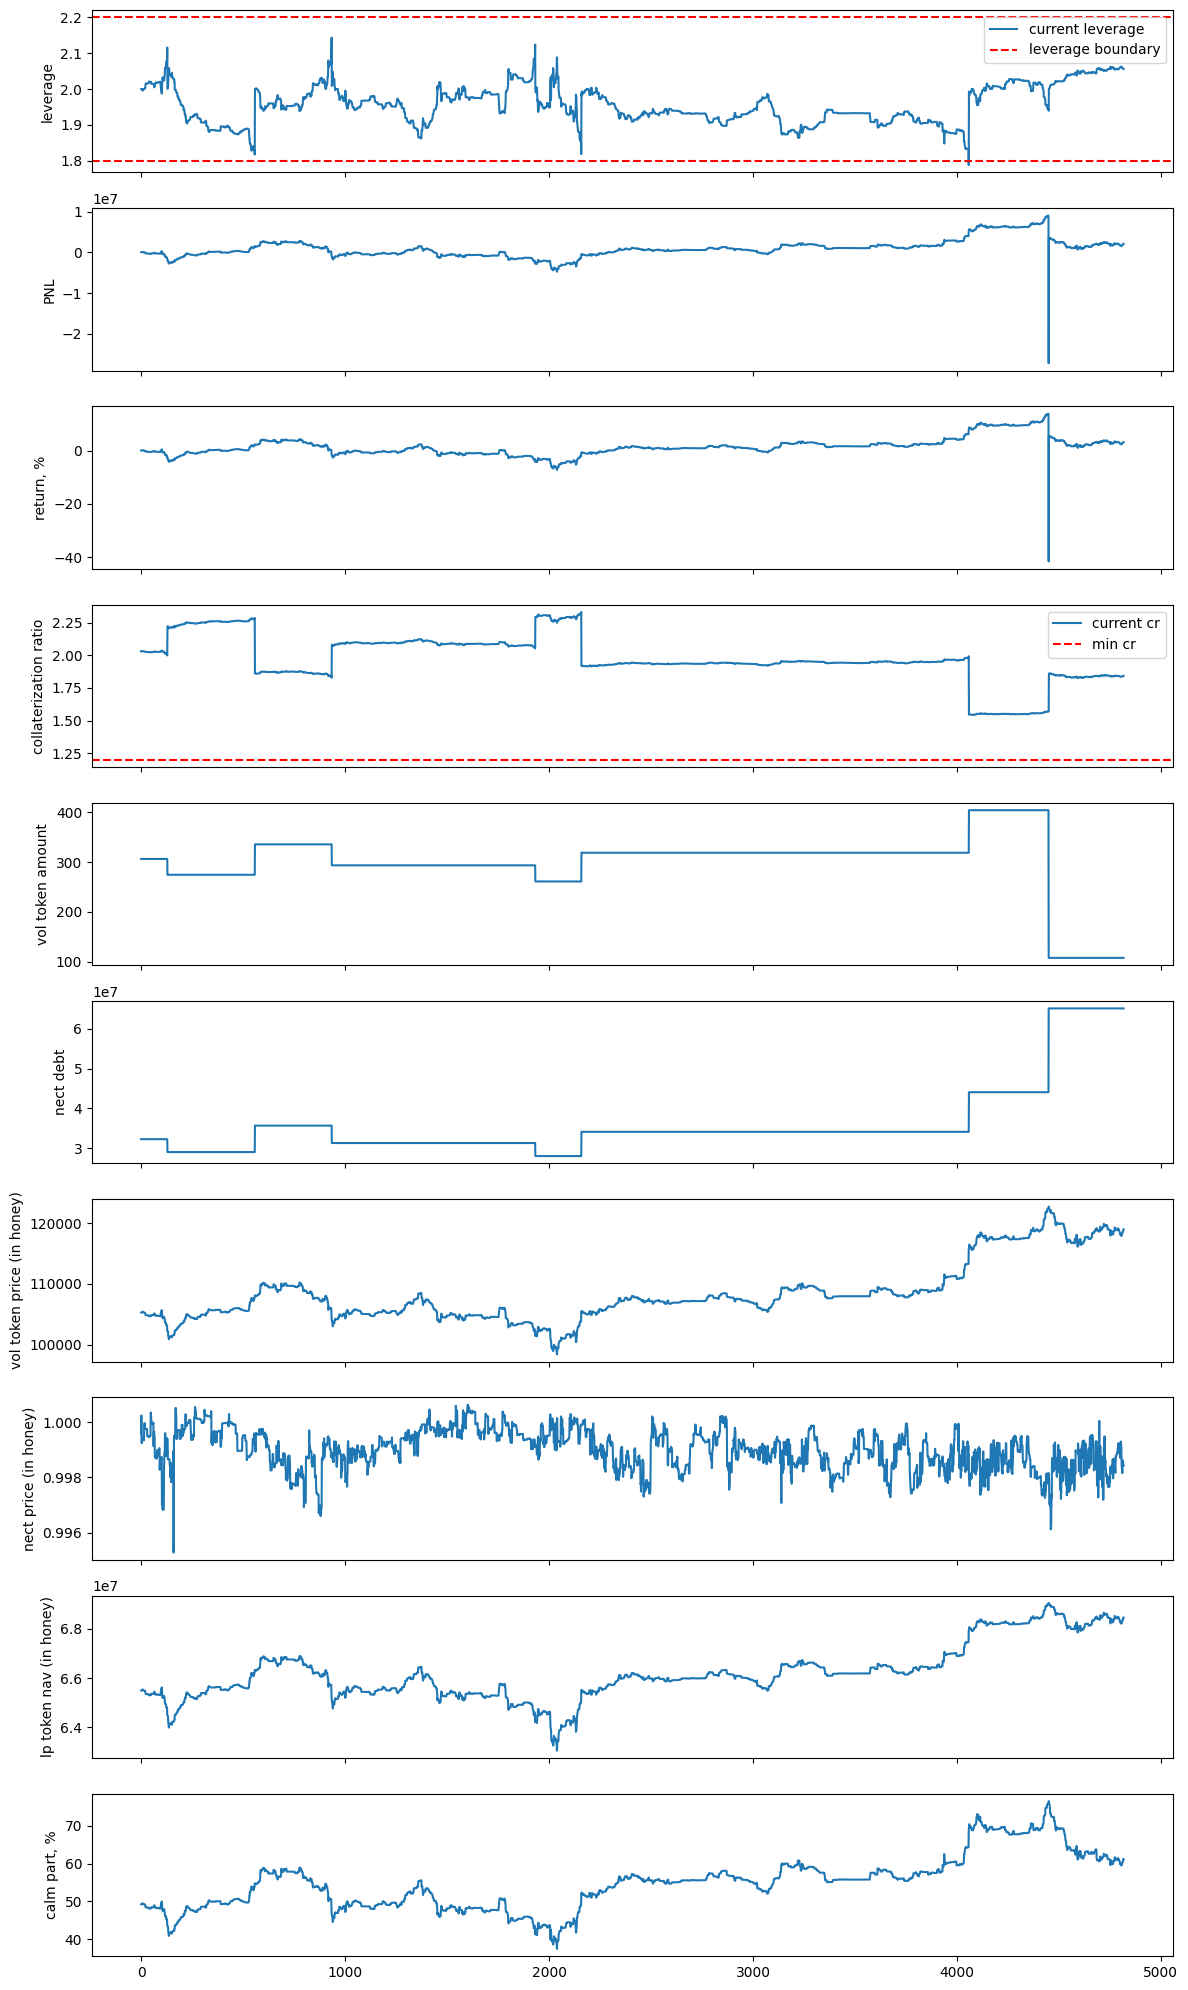

In [7]:
obs = eval_env.reset()   
done = False
while not done:
    action, _ = model_2.predict(obs, deterministic=True)  
    obs, rewards, dones, infos = eval_env.step(action)
    done = dones[0]
    if dones[0]:
        economic_metrics = infos[0].get('episode_economics')
        episode_history = infos[0].get('episode_history')
        not_doing = infos[0].get('0 action')  
        action_1 = infos[0].get('0.5 rebalancing') 
        action_2 = infos[0].get('0.75 rebalancing') 
        action_3 = infos[0].get('0.25 rebalancing')    
        break

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(episode_history, TOP_LEVERAGE, BOTTOM_LEVERAGE)
plot_economic_metrics(economic_metrics, TOP_LEVERAGE, BOTTOM_LEVERAGE)